# Latent bridge notebook



In [ ]:
import os
import sys
import pathlib
import subprocess

def pip_install(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + list(packages)
    subprocess.check_call(cmd)

pip_install(
    "transformers==4.49.0",
    "datasets==2.21.0",
    "accelerate==0.34.2",
    "sentencepiece>=0.2.0",
    "sacrebleu==2.4.3",
    "indic-nlp-library",
    "matplotlib",
    "pandas",
    "tqdm",
)

resources_dir = pathlib.Path("/content/indic_nlp_resources")
if not resources_dir.exists():
    subprocess.check_call(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/anoopkunchukuttan/indic_nlp_resources.git",
            str(resources_dir),
        ]
    )

print(f"Indic resources directory ready: {resources_dir} | exists={resources_dir.exists()}")

Indic resources directory ready: /content/indic_nlp_resources | exists=True


## Imports, runtime setup, and experiment config



In [ ]:
import gc
import json
import math
import os
import pathlib
import random
import re
import textwrap
import unicodedata
import warnings
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sacrebleu.metrics import CHRF
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoModelForSeq2SeqLM, AutoTokenizer, set_seed

from indicnlp import common, loader
from indicnlp.transliterate.unicode_transliterate import (
    ItransTransliterator,
    UnicodeIndicTransliterator,
)

warnings.filterwarnings("ignore")

INDIC_RESOURCES = "/content/indic_nlp_resources"
common.set_resources_path(INDIC_RESOURCES)
loader.load()

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32

if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

OUTPUT_DIR = pathlib.Path("/content/latent_bridge_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# One model at a time keeps free Colab stable.
PRIMARY_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct" if DEVICE.type == "cuda" else "Qwen/Qwen2.5-0.5B-Instruct"
OPTIONAL_SECOND_MODEL_ID = None  # Example: "Qwen/Qwen2.5-0.5B-Instruct"

ACTIVE_MODEL_IDS = [PRIMARY_MODEL_ID] + ([OPTIONAL_SECOND_MODEL_ID] if OPTIONAL_SECOND_MODEL_ID else [])

BOOTSTRAP_TRANSLATION_MODEL_ID = "facebook/nllb-200-distilled-600M"

# Keep these modest for a first Colab run.
WORD_PROBE_LIMIT_PER_PAIR = 15
PATCH_PROBE_LIMIT_PER_PAIR = 10
SENTENCE_PROBE_LIMIT_PER_PAIR = 10

WORD_MAX_NEW_TOKENS = 6
SENTENCE_MAX_NEW_TOKENS = 64
LATENT_THRESHOLD = 0.10

PAIR_SPECS = [
    {
        "name": "ben_to_guj",
        "src": "ben_Beng",
        "tgt": "guj_Gujr",
        "class": "test_cross_script_same_family",
    },
    {
        "name": "guj_to_tam",
        "src": "guj_Gujr",
        "tgt": "tam_Taml",
        "class": "test_cross_script_cross_family",
    },
    {
        "name": "asm_to_ben",
        "src": "asm_Beng",
        "tgt": "ben_Beng",
        "class": "control_same_script",
    },
    {
        "name": "hin_to_guj",
        "src": "hin_Deva",
        "tgt": "guj_Gujr",
        "class": "control_devanagari_in_input",
    },
]

print("Device:", DEVICE)
print("Torch dtype:", DTYPE)
print("Output dir:", OUTPUT_DIR)
print("Primary model:", PRIMARY_MODEL_ID)
print("Active pairs:")
print(pd.DataFrame(PAIR_SPECS))

Device: cuda
Torch dtype: torch.float16
Output dir: /content/latent_bridge_outputs
Primary model: Qwen/Qwen2.5-1.5B-Instruct
Active pairs:
         name       src       tgt                           class
0  ben_to_guj  ben_Beng  guj_Gujr   test_cross_script_same_family
1  guj_to_tam  guj_Gujr  tam_Taml  test_cross_script_cross_family
2  asm_to_ben  asm_Beng  ben_Beng             control_same_script
3  hin_to_guj  hin_Deva  guj_Gujr     control_devanagari_in_input


## Cell 3 — language metadata, script detection, and utility helpers

**Why we are doing this:**  
The later analysis needs a single source of truth for language names, expected script labels, pair names, FLORES column names, and basic script classification.



In [ ]:
LANG_INFO: Dict[str, Dict[str, Any]] = {
    "eng_Latn": {"name": "English", "indic_code": None, "script_label": "Latin"},
    "hin_Deva": {"name": "Hindi", "indic_code": "hi", "script_label": "Devanagari"},
    "ben_Beng": {"name": "Bengali", "indic_code": "bn", "script_label": "Bengali"},
    # Assamese is handled through the Bengali block for deterministic script conversion.
    "asm_Beng": {"name": "Assamese", "indic_code": "bn", "script_label": "Bengali"},
    "guj_Gujr": {"name": "Gujarati", "indic_code": "gu", "script_label": "Gujarati"},
    "tam_Taml": {"name": "Tamil", "indic_code": "ta", "script_label": "Tamil"},
    "ory_Orya": {"name": "Odia", "indic_code": "or", "script_label": "Oriya"},
    "mal_Mlym": {"name": "Malayalam", "indic_code": "ml", "script_label": "Malayalam"},
    "pan_Guru": {"name": "Punjabi", "indic_code": "pa", "script_label": "Gurmukhi"},
    "mar_Deva": {"name": "Marathi", "indic_code": "mr", "script_label": "Devanagari"},
}

ALL_ANALYSIS_LANGS = sorted(
    {
        "eng_Latn",
        "hin_Deva",
        "ben_Beng",
        "asm_Beng",
        "guj_Gujr",
        "tam_Taml",
        "ory_Orya",
        "mal_Mlym",
        "pan_Guru",
        "mar_Deva",
    }
)

SCRIPT_RANGES = {
    "Latin": [(0x0041, 0x007A), (0x00C0, 0x024F)],
    "Devanagari": [(0x0900, 0x097F)],
    "Bengali": [(0x0980, 0x09FF)],
    "Gurmukhi": [(0x0A00, 0x0A7F)],
    "Gujarati": [(0x0A80, 0x0AFF)],
    "Oriya": [(0x0B00, 0x0B7F)],
    "Tamil": [(0x0B80, 0x0BFF)],
    "Malayalam": [(0x0D00, 0x0D7F)],
}

def sort_flores_pair_name(lang_a: str, lang_b: str) -> str:
    return "-".join(sorted([lang_a, lang_b]))

def flores_sentence_col(lang_code: str) -> str:
    return f"sentence_{lang_code}"

def safe_text(x: Any) -> str:
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x).strip()

def word_count(text: str) -> int:
    return len([tok for tok in safe_text(text).split() if tok.strip()])

def script_of_char(ch: str) -> str:
    cp = ord(ch)
    for label, ranges in SCRIPT_RANGES.items():
        for start, end in ranges:
            if start <= cp <= end:
                return label
    if ch.strip() == "":
        return "Space"
    if unicodedata.category(ch).startswith("P"):
        return "Punct"
    if unicodedata.category(ch).startswith("N"):
        return "Number"
    return "Other"

def detect_script_label(text: str) -> str:
    labels = [script_of_char(ch) for ch in safe_text(text) if script_of_char(ch) not in {"Space", "Punct", "Number"}]
    if not labels:
        return "Other"
    uniq = sorted(set(labels))
    if len(uniq) == 1:
        return uniq[0]
    return "Mixed"

print(pd.DataFrame(LANG_INFO).T[["name", "indic_code", "script_label"]])
for sample in ["sun", "सूरज", "সূর্য", "સૂર્ય", "சூரியன்"]:
    print(sample, "->", detect_script_label(sample))

               name indic_code script_label
eng_Latn    English       None        Latin
hin_Deva      Hindi         hi   Devanagari
ben_Beng    Bengali         bn      Bengali
asm_Beng   Assamese         bn      Bengali
guj_Gujr   Gujarati         gu     Gujarati
tam_Taml      Tamil         ta        Tamil
ory_Orya       Odia         or        Oriya
mal_Mlym  Malayalam         ml    Malayalam
pan_Guru    Punjabi         pa     Gurmukhi
mar_Deva    Marathi         mr   Devanagari
sun -> Latin
सूरज -> Devanagari
সূর্য -> Bengali
સૂર્ય -> Gujarati
சூரியன் -> Tamil


## Cell 4 — bootstrap a word-level concept lexicon with NLLB

**Why we are doing this:**  
The mechanistic part of the study needs a word-level probe set. Instead of hand-entering everything first, this cell bootstraps an initial lexicon by translating a small English concept list into the analysis languages. You should still review the CSV after this step.

A dataframe with one row per English concept and one column per language. It is also saved to disk as `concept_lexicon_bootstrap.csv`.

In [ ]:
CONCEPTS_EN = [
    "water", "sun", "moon", "star", "flower", "tree", "river", "mountain",
    "house", "door", "window", "road", "book", "school", "teacher", "student",
    "food", "rice", "milk", "bread", "music", "dance", "friend", "family",
    "child", "mother", "father", "day", "night", "morning", "happy", "sad",
    "small", "big", "fast", "slow", "red", "blue", "green", "white",
]

BOOTSTRAP_LANGS = sorted(
    {
        "hin_Deva",
        "ben_Beng",
        "asm_Beng",
        "guj_Gujr",
        "tam_Taml",
        "ory_Orya",
        "mal_Mlym",
        "pan_Guru",
        "mar_Deva",
    }
)

BOOTSTRAP_PATH = OUTPUT_DIR / "concept_lexicon_bootstrap.csv"

def cleanup_torch():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def load_seq2seq_model(model_id: str):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model_kwargs = {}
    if DEVICE.type == "cuda":
        model_kwargs["torch_dtype"] = torch.float16
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id, **model_kwargs)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model

def batch_translate_nllb(
    texts: Sequence[str],
    src_lang: str,
    tgt_lang: str,
    tokenizer,
    model,
    batch_size: int = 8,
    max_new_tokens: int = 16,
) -> List[str]:
    tokenizer.src_lang = src_lang
    outputs: List[str] = []
    idx = 0
    while idx < len(texts):
        batch = list(texts[idx : idx + batch_size])
        try:
            encoded = tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
            encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
            with torch.no_grad():
                generated = model.generate(
                    **encoded,
                    forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_lang),
                    do_sample=False,
                    max_new_tokens=max_new_tokens,
                )
            decoded = tokenizer.batch_decode(generated, skip_special_tokens=True)
            outputs.extend([safe_text(x) for x in decoded])
            idx += batch_size
        except torch.cuda.OutOfMemoryError:
            cleanup_torch()
            if batch_size == 1:
                raise
            batch_size = max(1, batch_size // 2)
            print(f"OOM during NLLB bootstrap; retrying with batch_size={batch_size}")
    return outputs

if BOOTSTRAP_PATH.exists():
    lexicon_bootstrap = pd.read_csv(BOOTSTRAP_PATH)
else:
    nllb_tokenizer, nllb_model = load_seq2seq_model(BOOTSTRAP_TRANSLATION_MODEL_ID)
    data = {"concept_en": CONCEPTS_EN}
    for tgt_lang in BOOTSTRAP_LANGS:
        translations = batch_translate_nllb(
            texts=CONCEPTS_EN,
            src_lang="eng_Latn",
            tgt_lang=tgt_lang,
            tokenizer=nllb_tokenizer,
            model=nllb_model,
            batch_size=8,
            max_new_tokens=16,
        )
        data[tgt_lang] = translations
    lexicon_bootstrap = pd.DataFrame(data)
    lexicon_bootstrap.to_csv(BOOTSTRAP_PATH, index=False)
    del nllb_model, nllb_tokenizer
    cleanup_torch()

print(f"Saved bootstrap lexicon to: {BOOTSTRAP_PATH}")
display(lexicon_bootstrap.head())

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Saved bootstrap lexicon to: /content/latent_bridge_outputs/concept_lexicon_bootstrap.csv


,concept_en,asm_Beng,ben_Beng,guj_Gujr,hin_Deva,mal_Mlym,mar_Deva,ory_Orya,pan_Guru,tam_Taml
0,water,পানী,জল,પાણી,जल,വെള്ളം,पाणी,ପାଣି,ਪਾਣੀ,நீர்
1,sun,সূৰ্য,সূর্য,સૂર્ય,सूर्य,സൂര്യൻ,सूर्य,ସୂର୍ଯ୍ୟ,ਸੂਰਜ,சூரியன்
2,moon,চন্দ্ৰ,চাঁদ,ચંદ્ર,चंद्रमा,ചന്ദ്രൻ,चंद्र,ଚନ୍ଦ୍ରମା,ਚੰਦਰਮਾ,நிலவு
3,star,নক্ষত্ৰ,তারকা,તારા,तारा,നക്ഷത്രം,तारा,ତାରା,ਤਾਰਾ,நட்சத்திரம்
4,flower,ফুল,ফুল,ફૂલ,फूल,പൂവ്,फुल,ଫୁଲ,ਫੁੱਲ,பூ


## Cell 5 — derive Romanized and Devanagari variants, then create a manual-review table

**Why we are doing this:**  
The bridge analysis compares native forms with Romanized forms and same-language Devanagari transliterations. This cell derives those deterministic script variants and writes a reviewable CSV.


A long-format lexicon table with columns for `native_text`, `roman_itrans`, and `devanagari_translit`. It is saved as `concept_lexicon_derived.csv`. If we later upload `/content/lexicon_reviewed.csv`, the notebook will use that instead.

In [ ]:
LEXICON_DERIVED_PATH = OUTPUT_DIR / "concept_lexicon_derived.csv"
LEXICON_REVIEWED_PATH = pathlib.Path("/content/lexicon_reviewed.csv")

def to_devanagari(text: str, flores_code: str) -> str:
    text = safe_text(text)
    if not text:
        return ""
    indic_code = LANG_INFO[flores_code]["indic_code"]
    if indic_code is None:
        return text
    if LANG_INFO[flores_code]["script_label"] == "Devanagari":
        return text
    return safe_text(UnicodeIndicTransliterator.transliterate(text, indic_code, "hi"))

def to_roman_itrans(text: str, flores_code: str) -> str:
    text = safe_text(text)
    if not text:
        return ""
    indic_code = LANG_INFO[flores_code]["indic_code"]
    if indic_code is None:
        return text
    return safe_text(ItransTransliterator.to_itrans(text, indic_code))

if LEXICON_DERIVED_PATH.exists():
    lexicon_derived = pd.read_csv(LEXICON_DERIVED_PATH)
else:
    rows = []
    for _, row in lexicon_bootstrap.iterrows():
        concept = safe_text(row["concept_en"])
        for lang in BOOTSTRAP_LANGS:
            native_text = safe_text(row.get(lang, ""))
            rows.append(
                {
                    "concept_en": concept,
                    "lang": lang,
                    "lang_name": LANG_INFO[lang]["name"],
                    "native_text": native_text,
                    "roman_itrans": to_roman_itrans(native_text, lang),
                    "devanagari_translit": to_devanagari(native_text, lang),
                    "manual_reviewed": False,
                    "quality_note": "",
                }
            )
    lexicon_derived = pd.DataFrame(rows)
    lexicon_derived["native_script_detected"] = lexicon_derived["native_text"].map(detect_script_label)
    lexicon_derived["roman_script_detected"] = lexicon_derived["roman_itrans"].map(detect_script_label)
    lexicon_derived["devanagari_script_detected"] = lexicon_derived["devanagari_translit"].map(detect_script_label)
    lexicon_derived["roman_equals_native"] = (
        lexicon_derived["roman_itrans"].fillna("") == lexicon_derived["native_text"].fillna("")
    )
    lexicon_derived["deva_equals_native"] = (
        lexicon_derived["devanagari_translit"].fillna("") == lexicon_derived["native_text"].fillna("")
    )
    lexicon_derived.to_csv(LEXICON_DERIVED_PATH, index=False)

if LEXICON_REVIEWED_PATH.exists():
    lexicon_df = pd.read_csv(LEXICON_REVIEWED_PATH)
    print(f"Using reviewed lexicon from: {LEXICON_REVIEWED_PATH}")
else:
    lexicon_df = lexicon_derived.copy()
    print("No reviewed lexicon found; using the derived bootstrap table.")
    print("If you want manual cleanup, download concept_lexicon_derived.csv, edit it, upload it as /content/lexicon_reviewed.csv, then rerun this cell.")

display(lexicon_df.head(10))

No reviewed lexicon found; using the derived bootstrap table.
If you want manual cleanup, download concept_lexicon_derived.csv, edit it, upload it as /content/lexicon_reviewed.csv, then rerun this cell.


,concept_en,lang,lang_name,native_text,roman_itrans,devanagari_translit,manual_reviewed,quality_note,native_script_detected,roman_script_detected,devanagari_script_detected,roman_equals_native,deva_equals_native
0,water,asm_Beng,Assamese,পানী,paanii,पानी,False,,Bengali,Latin,Devanagari,False,False
1,water,ben_Beng,Bengali,জল,jala,जल,False,,Bengali,Latin,Devanagari,False,False
2,water,guj_Gujr,Gujarati,પાણી,paaNii,पाणी,False,,Gujarati,Latin,Devanagari,False,False
3,water,hin_Deva,Hindi,जल,jala,जल,False,,Devanagari,Latin,Devanagari,False,True
4,water,mal_Mlym,Malayalam,വെള്ളം,v.eldlda.m,वॆळ्ळं,False,,Malayalam,Latin,Devanagari,False,False
5,water,mar_Deva,Marathi,पाणी,paaNii,पाणी,False,,Devanagari,Latin,Devanagari,False,True
6,water,ory_Orya,Odia,ପାଣି,paaNi,पाणि,False,,Oriya,Latin,Devanagari,False,False
7,water,pan_Guru,Punjabi,ਪਾਣੀ,paaNii,पाणी,False,,Gurmukhi,Latin,Devanagari,False,False
8,water,tam_Taml,Tamil,நீர்,niir,नीर्,False,,Tamil,Latin,Devanagari,False,False
9,sun,asm_Beng,Assamese,সূৰ্য,suuya,सूৰ्य,False,,Bengali,Latin,Mixed,False,False


## Cell 6 — load the main causal model

**Why we are doing this:**  
All remaining analysis uses one causal LLM at a time. Keeping one model loaded is the safest choice on free Colab.

The model id, whether a fast tokenizer is available, the tokenizer pad token, and the number of transformer layers detected.

In [ ]:
def load_causal_model_bundle(model_id: str):
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    model_kwargs = {"low_cpu_mem_usage": True}
    if DEVICE.type == "cuda":
        model_kwargs["torch_dtype"] = torch.float16
    model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model

def maybe_getattr(obj: Any, path: str) -> Optional[Any]:
    cur = obj
    for part in path.split("."):
        if not hasattr(cur, part):
            return None
        cur = getattr(cur, part)
    return cur

def get_transformer_layers(model) -> Sequence[torch.nn.Module]:
    candidate_paths = [
        "model.layers",
        "transformer.h",
        "gpt_neox.layers",
        "model.decoder.layers",
        "layers",
    ]
    for path in candidate_paths:
        value = maybe_getattr(model, path)
        if value is not None and hasattr(value, "__len__"):
            return value
    raise ValueError("Could not find transformer layers for this model architecture.")

def get_final_norm_module(model) -> Optional[torch.nn.Module]:
    candidate_paths = [
        "model.norm",
        "transformer.ln_f",
        "gpt_neox.final_layer_norm",
        "model.decoder.final_layer_norm",
        "model.final_layernorm",
        "transformer.final_layer_norm",
    ]
    for path in candidate_paths:
        value = maybe_getattr(model, path)
        if value is not None:
            return value
    return None

def apply_final_norm(model, hidden_states: torch.Tensor) -> torch.Tensor:
    norm = get_final_norm_module(model)
    return norm(hidden_states) if norm is not None else hidden_states

def get_output_head(model) -> torch.nn.Module:
    head = model.get_output_embeddings()
    if head is None:
        raise ValueError("Could not find output embedding / LM head.")
    return head

tokenizer, model = load_causal_model_bundle(PRIMARY_MODEL_ID)
num_layers = len(get_transformer_layers(model))
print("Model:", PRIMARY_MODEL_ID)
print("Fast tokenizer:", tokenizer.is_fast)
print("Pad token:", tokenizer.pad_token)
print("Number of transformer layers:", num_layers)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model: Qwen/Qwen2.5-1.5B-Instruct
Fast tokenizer: True
Pad token: <|endoftext|>
Number of transformer layers: 28


## Cell 7 — tokenizer audit

**Why we are doing this:**  
Before doing any mechanistic script analysis, we need to know whether the tokenizer handles the target scripts cleanly enough. Bad byte-like fragmentation can make the bridge curves hard to interpret.

A summary table and a token-level preview. Rows with very high token counts for short words, lots of mixed-script pieces, or obvious byte-like fragments are warning signs.

In [ ]:
TOKEN_AUDIT_PATH = OUTPUT_DIR / f"token_audit__{PRIMARY_MODEL_ID.replace('/', '__')}.csv"

def clean_token_piece(piece: str) -> str:
    piece = piece.replace("▁", "").replace("Ġ", "").replace("Ċ", "").replace("##", "")
    return piece.strip()

def is_byte_like_piece(piece: str) -> bool:
    piece = safe_text(piece)
    if not piece:
        return False
    if re.fullmatch(r"<0x[0-9A-Fa-f]{2}>", piece):
        return True
    if "\ufffd" in piece:
        return True
    return False

def audit_single_text(tokenizer, text: str) -> Dict[str, Any]:
    enc = tokenizer(text, add_special_tokens=False)
    ids = enc["input_ids"]
    pieces = tokenizer.convert_ids_to_tokens(ids)
    decoded_pieces = [
        tokenizer.decode([tid], skip_special_tokens=False, clean_up_tokenization_spaces=False)
        for tid in ids
    ]
    cleaned = [clean_token_piece(x) for x in decoded_pieces]
    piece_scripts = [detect_script_label(x) for x in cleaned]
    return {
        "text": text,
        "num_chars": len(text),
        "num_tokens": len(ids),
        "tokens_per_char": (len(ids) / max(1, len(text))),
        "token_ids": ids,
        "token_pieces": pieces,
        "decoded_pieces": decoded_pieces,
        "piece_scripts": piece_scripts,
        "byte_like_piece_count": int(sum(is_byte_like_piece(x) for x in pieces)),
        "mixed_piece_count": int(sum(lbl == "Mixed" for lbl in piece_scripts)),
        "other_piece_count": int(sum(lbl == "Other" for lbl in piece_scripts)),
    }

audit_samples = []
for lang in sorted(set(lexicon_df["lang"].tolist())):
    sample_rows = lexicon_df[lexicon_df["lang"] == lang].head(5)
    for _, row in sample_rows.iterrows():
        audit = audit_single_text(tokenizer, safe_text(row["native_text"]))
        audit["lang"] = lang
        audit["lang_name"] = LANG_INFO[lang]["name"]
        audit["sample_kind"] = "native_word"
        audit_samples.append(audit)

token_audit_df = pd.DataFrame(audit_samples)
token_audit_df.to_csv(TOKEN_AUDIT_PATH, index=False)

summary = (
    token_audit_df.groupby(["lang", "lang_name"])
    .agg(
        mean_tokens=("num_tokens", "mean"),
        mean_tokens_per_char=("tokens_per_char", "mean"),
        mean_byte_like_pieces=("byte_like_piece_count", "mean"),
        mean_mixed_pieces=("mixed_piece_count", "mean"),
        mean_other_pieces=("other_piece_count", "mean"),
    )
    .reset_index()
    .sort_values(["mean_tokens_per_char", "mean_byte_like_pieces"], ascending=[False, False])
)

print(f"Saved tokenizer audit to: {TOKEN_AUDIT_PATH}")
display(summary)
display(token_audit_df[["lang", "text", "num_tokens", "token_pieces", "decoded_pieces", "piece_scripts"]].head(8))

Saved tokenizer audit to: /content/latent_bridge_outputs/token_audit__Qwen__Qwen2.5-1.5B-Instruct.csv


,lang,lang_name,mean_tokens,mean_tokens_per_char,mean_byte_like_pieces,mean_mixed_pieces,mean_other_pieces
6,ory_Orya,Odia,11.8,2.230952,0.0,0.0,11.8
2,guj_Gujr,Gujarati,7.4,1.770000,0.0,0.0,6.4
7,pan_Guru,Punjabi,7.4,1.683333,0.0,0.0,6.0
8,tam_Taml,Tamil,7.0,1.286753,0.0,1.0,3.4
0,asm_Beng,Assamese,6.2,1.258571,0.0,0.8,3.2
4,mal_Mlym,Malayalam,7.2,1.175000,0.0,1.2,3.2
1,ben_Beng,Bengali,4.2,1.106667,0.0,0.6,1.4
3,hin_Deva,Hindi,4.4,1.078095,0.0,0.4,1.2
5,mar_Deva,Marathi,4.2,1.000000,0.0,0.6,1.0


,lang,text,num_tokens,token_pieces,decoded_pieces,piece_scripts
0,asm_Beng,পানী,5,"[à¦ª, à¦¾à¦, ¨, à§, Ģ]","[প, া�, �, �, �]","[Bengali, Mixed, Other, Other, Other]"
1,asm_Beng,সূৰ্য,7,"[à¦¸, à§, Ĥ, à§, °, à§įà¦, ¯]","[স, �, �, �, �, ্�, �]","[Bengali, Other, Other, Other, Other, Mixed, O..."
2,asm_Beng,চন্দ্ৰ,7,"[à¦ļ, à¦¨, à§įà¦, ¦, à§į, à§, °]","[চ, ন, ্�, �, ্, �, �]","[Bengali, Bengali, Mixed, Other, Bengali, Othe..."
3,asm_Beng,নক্ষত্ৰ,8,"[à¦¨, à¦ķ, à§įà¦, ·, à¦¤, à§į, à§, °]","[ন, ক, ্�, �, ত, ্, �, �]","[Bengali, Bengali, Mixed, Other, Bengali, Beng..."
4,asm_Beng,ফুল,4,"[à¦«, à§, ģ, à¦²]","[ফ, �, �, ল]","[Bengali, Other, Other, Bengali]"
5,ben_Beng,জল,2,"[à¦ľ, à¦²]","[জ, ল]","[Bengali, Bengali]"
6,ben_Beng,সূর্য,6,"[à¦¸, à§, Ĥ, à¦°, à§įà¦, ¯]","[স, �, �, র, ্�, �]","[Bengali, Other, Other, Bengali, Mixed, Other]"
7,ben_Beng,চাঁদ,4,"[à¦ļ, à¦¾à¦, ģ, à¦¦]","[চ, া�, �, দ]","[Bengali, Mixed, Other, Bengali]"


## Cell 8 — build the pair-specific word probe dataset

**Why we are doing this:**  
The bridge analysis is pair-specific. This cell joins the long-format lexicon into a wide table so each row contains all the source and target variants needed for one concept under one language pair.


A dataframe with one row per `(concept, pair)` containing source native / Roman / Devanagari, target native / Roman / Devanagari, the English gloss, and the Hindi lexical form.

In [ ]:
WORD_PROBE_PATH = OUTPUT_DIR / "word_probe_pairs.csv"

def build_lexicon_lookup(df: pd.DataFrame) -> Dict[Tuple[str, str], Dict[str, Any]]:
    lookup: Dict[Tuple[str, str], Dict[str, Any]] = {}
    for _, row in df.iterrows():
        key = (safe_text(row["concept_en"]), safe_text(row["lang"]))
        lookup[key] = row.to_dict()
    return lookup

lex_lookup = build_lexicon_lookup(lexicon_df)

def build_word_probe_pairs(
    concepts: Sequence[str],
    pair_specs: Sequence[Dict[str, str]],
    lookup: Dict[Tuple[str, str], Dict[str, Any]],
) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for concept in concepts:
        hindi_row = lookup.get((concept, "hin_Deva"))
        if hindi_row is None:
            continue
        for spec in pair_specs:
            src_row = lookup.get((concept, spec["src"]))
            tgt_row = lookup.get((concept, spec["tgt"]))
            if src_row is None or tgt_row is None:
                continue
            rows.append(
                {
                    "concept_en": concept,
                    "pair_name": spec["name"],
                    "pair_class": spec["class"],
                    "src_lang": spec["src"],
                    "tgt_lang": spec["tgt"],
                    "src_lang_name": LANG_INFO[spec["src"]]["name"],
                    "tgt_lang_name": LANG_INFO[spec["tgt"]]["name"],
                    "src_native": safe_text(src_row["native_text"]),
                    "src_roman": safe_text(src_row["roman_itrans"]),
                    "src_devanagari": safe_text(src_row["devanagari_translit"]),
                    "tgt_native": safe_text(tgt_row["native_text"]),
                    "tgt_roman": safe_text(tgt_row["roman_itrans"]),
                    "tgt_devanagari": safe_text(tgt_row["devanagari_translit"]),
                    "hindi_native": safe_text(hindi_row["native_text"]),
                }
            )
    out = pd.DataFrame(rows)
    for col in [
        "src_native",
        "src_roman",
        "src_devanagari",
        "tgt_native",
        "tgt_roman",
        "tgt_devanagari",
        "hindi_native",
    ]:
        out = out[out[col].fillna("").str.len() > 0]
    return out.reset_index(drop=True)

word_probe_df = build_word_probe_pairs(CONCEPTS_EN, PAIR_SPECS, lex_lookup)
word_probe_df.to_csv(WORD_PROBE_PATH, index=False)

print(f"Saved word probes to: {WORD_PROBE_PATH}")
display(word_probe_df.head(10))
print(word_probe_df.groupby(["pair_name", "pair_class"]).size())

Saved word probes to: /content/latent_bridge_outputs/word_probe_pairs.csv


,concept_en,pair_name,pair_class,src_lang,tgt_lang,src_lang_name,tgt_lang_name,src_native,src_roman,src_devanagari,tgt_native,tgt_roman,tgt_devanagari,hindi_native
0,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,জল,jala,जल,પાણી,paaNii,पाणी,जल
1,water,guj_to_tam,test_cross_script_cross_family,guj_Gujr,tam_Taml,Gujarati,Tamil,પાણી,paaNii,पाणी,நீர்,niir,नीर्,जल
2,water,asm_to_ben,control_same_script,asm_Beng,ben_Beng,Assamese,Bengali,পানী,paanii,पानी,জল,jala,जल,जल
3,water,hin_to_guj,control_devanagari_in_input,hin_Deva,guj_Gujr,Hindi,Gujarati,जल,jala,जल,પાણી,paaNii,पाणी,जल
4,sun,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,সূর্য,suurya,सूर्य,સૂર્ય,suurya,सूर्य,सूर्य
5,sun,guj_to_tam,test_cross_script_cross_family,guj_Gujr,tam_Taml,Gujarati,Tamil,સૂર્ય,suurya,सूर्य,சூரியன்,chuuriya*n,चूरियऩ्,सूर्य
6,sun,asm_to_ben,control_same_script,asm_Beng,ben_Beng,Assamese,Bengali,সূৰ্য,suuya,सूৰ्य,সূর্য,suurya,सूर्य,सूर्य
7,sun,hin_to_guj,control_devanagari_in_input,hin_Deva,guj_Gujr,Hindi,Gujarati,सूर्य,suurya,सूर्य,સૂર્ય,suurya,सूर्य,सूर्य
8,moon,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,চাঁদ,chaaँda,चाँद,ચંદ્ર,cha.mdra,चंद्र,चंद्रमा
9,moon,guj_to_tam,test_cross_script_cross_family,guj_Gujr,tam_Taml,Gujarati,Tamil,ચંદ્ર,cha.mdra,चंद्र,நிலவு,nilavu,निलवु,चंद्रमा


pair_name   pair_class                    
asm_to_ben  control_same_script               40
ben_to_guj  test_cross_script_same_family     40
guj_to_tam  test_cross_script_cross_family    40
hin_to_guj  control_devanagari_in_input       40
dtype: int64


## Cell 9 — build the short-sentence probe subset from FLORES

**Why we are doing this:**  
Word-level probes are best for the mechanistic work, but we still want a small sentence-level set for later explicit-pivot evaluation. We use the `all` FLORES config so each sentence row also gives aligned English and Hindi controls.

**What you should expect as output:**  
A short sentence subset per active pair with native source, Romanized source, Devanagari-transliterated source, aligned English source, aligned Hindi source, and the target reference sentence.

In [ ]:
SENTENCE_PROBE_PATH = OUTPUT_DIR / "sentence_probe_subset.csv"

# Added trust_remote_code=True to avoid the interactive prompt hang
flores_all_dev = load_dataset("facebook/flores", "all", split="dev", trust_remote_code=True).to_pandas()

def build_sentence_probe_subset(
    flores_df: pd.DataFrame,
    pair_specs: Sequence[Dict[str, str]],
    max_rows_per_pair: int = 10,
    max_source_words: int = 12,
) -> pd.DataFrame:
    rows: List[pd.DataFrame] = []
    for spec in pair_specs:
        src_col = flores_sentence_col(spec["src"])
        tgt_col = flores_sentence_col(spec["tgt"])
        eng_col = flores_sentence_col("eng_Latn")
        hin_col = flores_sentence_col("hin_Deva")

        # Select required columns, handling potential duplicates if src == tgt script
        keep_cols = list(set(["id", eng_col, hin_col, src_col, tgt_col]))
        sub = flores_df[keep_cols].copy()

        # Assign content to fixed names explicitly to avoid rename collision issues
        sub["src_text"] = flores_df[src_col]
        sub["tgt_text"] = flores_df[tgt_col]
        sub["english_text"] = flores_df[eng_col]
        sub["hindi_text"] = flores_df[hin_col]

        sub["pair_name"] = spec["name"]
        sub["pair_class"] = spec["class"]
        sub["src_lang"] = spec["src"]
        sub["tgt_lang"] = spec["tgt"]
        sub["src_lang_name"] = LANG_INFO[spec["src"]]["name"]
        sub["tgt_lang_name"] = LANG_INFO[spec["tgt"]]["name"]

        sub["src_word_count"] = sub["src_text"].map(word_count)
        sub = sub[sub["src_word_count"] <= max_source_words].copy()

        sub["src_roman"] = sub["src_text"].map(lambda x: to_roman_itrans(x, spec["src"]))
        sub["src_devanagari"] = sub["src_text"].map(lambda x: to_devanagari(x, spec["src"]))

        sub = sub.head(max_rows_per_pair)
        rows.append(sub)

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)

sentence_probe_df = build_sentence_probe_subset(
    flores_df=flores_all_dev,
    pair_specs=PAIR_SPECS,
    max_rows_per_pair=SENTENCE_PROBE_LIMIT_PER_PAIR,
    max_source_words=12,
)
sentence_probe_df.to_csv(SENTENCE_PROBE_PATH, index=False)

print(f"Saved sentence probes to: {SENTENCE_PROBE_PATH}")
display(sentence_probe_df.head(8))
print(sentence_probe_df.groupby(["pair_name", "pair_class"]).size())

Saved sentence probes to: /content/latent_bridge_outputs/sentence_probe_subset.csv


,id,sentence_eng_Latn,sentence_hin_Deva,sentence_ben_Beng,sentence_guj_Gujr,src_text,tgt_text,english_text,hindi_text,pair_name,pair_class,src_lang,tgt_lang,src_lang_name,tgt_lang_name,src_word_count,src_roman,src_devanagari,sentence_tam_Taml,sentence_asm_Beng
0,4,The pilot was identified as Squadron Leader Di...,पायलट की पहचान स्क्वाड्रन लीडर दिलोकृत पटावी क...,পাইলটটি স্কোয়াড্রন লিডার দিলোকৃত পাত্তাভী হিসে...,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,পাইলটটি স্কোয়াড্রন লিডার দিলোকৃত পাত্তাভী হিসে...,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,The pilot was identified as Squadron Leader Di...,पायलट की पहचान स्क्वाड्रन लीडर दिलोकृत पटावी क...,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,8,paailaTaTi skoaaDrana liDaara dilokR^ita paatt...,पाइलटटि स्कोय़ाड्रन लिडार दिलोकृत पात्ताभी हिसे...,NaN,NaN
1,6,28-year-old Vidal had joined Barça three seaso...,28 वर्षीय विडाल तीन सीजन पहले सेविला से बारका ...,২৮ বছর বয়সী ভিদাল ৩ বছর আগে সেভিয়া থেকে বার্সে...,28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,২৮ বছর বয়সী ভিদাল ৩ বছর আগে সেভিয়া থেকে বার্সে...,28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,28-year-old Vidal had joined Barça three seaso...,28 वर्षीय विडाल तीन सीजन पहले सेविला से बारका ...,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,12,28 baChara baय़sii bhidaala 3 baChara aage sebh...,२८ बछर बय़सी भिदाल ३ बछर आगे सेभिय़ा थेके बार्से...,NaN,NaN
2,7,"Since moving to the Catalan-capital, Vidal had...",कातलान की राजधानी (बार्सिलोना) में जाने के बाद...,কাতালান-রাজধানীতে আসার পর থেকে ভিদাল ক্লাবটির ...,કેટાલનની રાજધાનીમાં ગયા પછી વિડાલ ક્લબ માટે 49...,কাতালান-রাজধানীতে আসার পর থেকে ভিদাল ক্লাবটির ...,કેટાલનની રાજધાનીમાં ગયા પછી વિડાલ ક્લબ માટે 49...,"Since moving to the Catalan-capital, Vidal had...",कातलान की राजधानी (बार्सिलोना) में जाने के बाद...,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,11,kaataalaana-raajadhaaniite aasaara para theke ...,कातालान-राजधानीते आसार पर थेके भिदाल क्लाबटिर ...,NaN,NaN
3,9,"Just after 11:00, protesters blocked traffic o...","ठीक 11:00 बजे के बाद, व्हाइटहॉल में उत्तर की ओ...","11:00 টার ঠিক পরে, বিক্ষোভকারীরা হোয়াইটহলের উ...","11:00 વાગતાજ, વિરોધપ્રદર્શનકારીઓએ વાઇટહોલના નો...","11:00 টার ঠিক পরে, বিক্ষোভকারীরা হোয়াইটহলের উ...","11:00 વાગતાજ, વિરોધપ્રદર્શનકારીઓએ વાઇટહોલના નો...","Just after 11:00, protesters blocked traffic o...","ठीक 11:00 बजे के बाद, व्हाइटहॉल में उत्तर की ओ...",ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,10,"11:00 Taara Thika pare, bikShobhakaariiraa hoy...","11:00 टार ठिक परे, बिक्षोभकारीरा होय़ाइटहलेर उ...",NaN,NaN
4,12,Nadal's head to head record against the Canadi...,कनाडियन के खिलाफ नडाल का सीधा रिकॉर्ड 7-2 है।,কানাডার এই খেলোয়াড়ের বিরুদ্ধে নাদালের মুখোমুখি...,નાદલ અને કેનેડિયન વચ્ચે ની હરીફાઈ નો રેકોર્ડ 7...,কানাডার এই খেলোয়াড়ের বিরুদ্ধে নাদালের মুখোমুখি...,નાદલ અને કેનેડિયન વચ્ચે ની હરીફાઈ નો રેકોર્ડ 7...,Nadal's head to head record against the Canadi...,कनाडियन के खिलाफ नडाल का सीधा रिकॉर्ड 7-2 है।,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,11,kaanaaDaara ei kheloaaera biruddhe naadaalera ...,कानाडार एइ खेलोय़ाड़ेर बिरुद्धे नादालेर मुखोमुखि...,NaN,NaN
5,13,He recently lost against Raonic in the Brisban...,वे हाल ही में ब्रिस्बेन ओपन में रोनिक के खिलाफ...,সম্প্রতি তিনি ব্রিসবেন ওপেনে রাওনিকের বিপক্ষে ...,તાજેતરમાં બ્રિસ્બેન ઓપનમાં તેઓ રેઓનિક સામે હાર...,সম্প্রতি তিনি ব্রিসবেন ওপেনে রাওনিকের বিপক্ষে ...,તાજેતરમાં બ્રિસ્બેન ઓપનમાં તેઓ રેઓનિક સામે હાર...,He recently lost against Raonic in the Brisban...,वे हाल ही में ब्रिस्बेन ओपन में रोनिक के खिलाफ...,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,Bengali,Gujarati,7,samprati tini brisabena opene raaonikera bipak...,सम्प्रति तिनि ब्रिसबेन ओपेने राओनिकेर बिपक्षे ...,NaN,NaN
6,14,Nadal bagged 88% net points in the match winni...,फ़र्स्ट सर्व में नडाल को 76 मैच विनिंग पॉइंट्स...,নাদাল প্রথম সার্ভে ৭৬ পয়েন্ট নিয়ে ম্যাচটিতে ৮৮...,નડાલે પ્રથમ સર્વિસમાં 

pair_name   pair_class                    
asm_to_ben  control_same_script               10
ben_to_guj  test_cross_script_same_family     10
guj_to_tam  test_cross_script_cross_family    10
hin_to_guj  control_devanagari_in_input       10
dtype: int64


## Cell 10 — prompt builders, span extraction, candidate sequence helpers, and logit-lens tracing

**Why we are doing this:**  
This is the core mechanics cell. It defines the exact prompt format, how we find the source-word span reliably with a fast tokenizer, how we represent candidate bridge strings as token sequences, and how we trace layerwise next-token probability mass one generation step at a time.

**What you should expect as output:**  
No heavy computation yet. Just function definitions and a small sanity check confirming we can locate a source span.

In [ ]:
def make_word_translation_prompt(src_lang: str, tgt_lang: str, source_text: str) -> str:
    return (
        f"Translate the following {LANG_INFO[src_lang]['name']} word into {LANG_INFO[tgt_lang]['name']}.\n"
        f"Word: {source_text}\n"
        "Answer:"
    )

def make_word_to_english_prompt(src_lang: str, source_text: str) -> str:
    return (
        f"Translate the following {LANG_INFO[src_lang]['name']} word into English.\n"
        f"Word: {source_text}\n"
        "Answer:"
    )

def make_sentence_translation_prompt(src_label: str, tgt_lang: str, source_text: str) -> str:
    return (
        f"Translate the following sentence into {LANG_INFO[tgt_lang]['name']}.\n"
        f"Return only the translation in {LANG_INFO[tgt_lang]['name']}.\n"
        f"Source ({src_label}): {source_text}\n"
        "Answer:"
    )

def encode_prompt_with_marked_span(
    tokenizer,
    prefix: str,
    span_text: str,
    suffix: str,
    device: torch.device,
) -> Tuple[str, Dict[str, torch.Tensor], List[int]]:
    if not tokenizer.is_fast:
        raise ValueError("A fast tokenizer is required for exact source-span extraction.")
    full_text = prefix + span_text + suffix
    enc = tokenizer(
        full_text,
        return_tensors="pt",
        return_offsets_mapping=True,
        add_special_tokens=False,
    )
    offsets = enc.pop("offset_mapping")[0].tolist()
    start_char = len(prefix)
    end_char = start_char + len(span_text)
    positions = [i for i, (s, e) in enumerate(offsets) if e > start_char and s < end_char]
    if not positions:
        # Safe fallback: use the final token of the span segment.
        span_only = tokenizer(prefix + span_text, return_tensors="pt", add_special_tokens=False)
        last_pos = int(span_only["input_ids"].shape[1] - 1)
        positions = [last_pos]
        enc = tokenizer(full_text, return_tensors="pt", add_special_tokens=False)
    inputs = {
        k: v.to(device)
        for k, v in enc.items()
        if k != "token_type_ids"
    }
    if "attention_mask" not in inputs:
        inputs["attention_mask"] = torch.ones_like(inputs["input_ids"], device=device)
    return full_text, inputs, positions

def build_candidate_sequences(tokenizer, texts: Iterable[str]) -> List[Tuple[int, ...]]:
    seqs = set()
    for text in texts:
        text = safe_text(text)
        if not text:
            continue
        for variant in {text, f" {text}"}:
            ids = tokenizer(variant, add_special_tokens=False)["input_ids"]
            if ids:
                seqs.add(tuple(ids))
    return sorted(seqs)

def next_token_ids_for_prefix(
    candidate_sequences: Sequence[Tuple[int, ...]],
    generated_ids: Sequence[int],
) -> List[int]:
    prefix = tuple(generated_ids)
    next_ids = sorted(
        {
            seq[len(prefix)]
            for seq in candidate_sequences
            if len(seq) > len(prefix) and seq[: len(prefix)] == prefix
        }
    )
    return next_ids

def build_candidate_group_sequences(tokenizer, probe_row: Dict[str, Any]) -> Dict[str, List[Tuple[int, ...]]]:
    english_variants = {safe_text(probe_row["concept_en"]), safe_text(probe_row["concept_en"]).lower()}
    groups = {
        "english_gloss": build_candidate_sequences(tokenizer, english_variants),
        "target_roman": build_candidate_sequences(tokenizer, [probe_row["tgt_roman"]]),
        "target_devanagari": build_candidate_sequences(tokenizer, [probe_row["tgt_devanagari"]]),
        "hindi_lexical": build_candidate_sequences(tokenizer, [probe_row["hindi_native"]]),
        "target_native": build_candidate_sequences(tokenizer, [probe_row["tgt_native"]]),
    }
    return groups

def layerwise_candidate_mass_records(
    model,
    hidden_states: Sequence[torch.Tensor],
    candidate_next_ids: Dict[str, List[int]],
    step_idx: int,
    example_meta: Dict[str, Any],
) -> List[Dict[str, Any]]:
    output_head = get_output_head(model)
    records: List[Dict[str, Any]] = []
    # hidden_states[0] is the embedding output; hidden_states[1:] correspond to transformer block outputs.
    for layer_idx, hs in enumerate(hidden_states[1:]):
        last_hidden = hs[:, -1, :]
        normed = apply_final_norm(model, last_hidden)
        layer_logits = output_head(normed)
        layer_probs = torch.softmax(layer_logits.float(), dim=-1)[0]
        for group_name, next_ids in candidate_next_ids.items():
            mass = float(layer_probs[next_ids].sum().item()) if next_ids else 0.0
            records.append(
                {
                    **example_meta,
                    "layer": int(layer_idx),
                    "step": int(step_idx),
                    "group": group_name,
                    "mass": mass,
                }
            )
    return records

def greedy_trace_word_example(
    model,
    tokenizer,
    probe_row: Dict[str, Any],
    max_new_tokens: int = 6,
) -> Tuple[pd.DataFrame, str]:
    prompt = make_word_translation_prompt(
        src_lang=probe_row["src_lang"],
        tgt_lang=probe_row["tgt_lang"],
        source_text=probe_row["src_native"],
    )
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items() if k != "token_type_ids"}
    if "attention_mask" not in inputs:
        inputs["attention_mask"] = torch.ones_like(inputs["input_ids"], device=DEVICE)

    group_sequences = build_candidate_group_sequences(tokenizer, probe_row)
    generated_ids: List[int] = []
    records: List[Dict[str, Any]] = []

    example_meta = {
        "concept_en": probe_row["concept_en"],
        "pair_name": probe_row["pair_name"],
        "pair_class": probe_row["pair_class"],
        "src_lang": probe_row["src_lang"],
        "tgt_lang": probe_row["tgt_lang"],
    }

    for step_idx in range(max_new_tokens):
        with torch.no_grad():
            outputs = model(
                **inputs,
                output_hidden_states=True,
                use_cache=False,
                return_dict=True,
            )

        candidate_next_ids = {
            group_name: next_token_ids_for_prefix(group_sequences[group_name], generated_ids)
            for group_name in group_sequences
        }
        records.extend(
            layerwise_candidate_mass_records(
                model=model,
                hidden_states=outputs.hidden_states,
                candidate_next_ids=candidate_next_ids,
                step_idx=step_idx,
                example_meta=example_meta,
            )
        )

        next_id = int(outputs.logits[:, -1, :].argmax(dim=-1).item())
        generated_ids.append(next_id)

        next_token = torch.tensor([[next_id]], device=DEVICE, dtype=inputs["input_ids"].dtype)
        inputs["input_ids"] = torch.cat([inputs["input_ids"], next_token], dim=1)
        inputs["attention_mask"] = torch.cat(
            [
                inputs["attention_mask"],
                torch.ones((1, 1), device=DEVICE, dtype=inputs["attention_mask"].dtype),
            ],
            dim=1,
        )

        if tokenizer.eos_token_id is not None and next_id == tokenizer.eos_token_id:
            break

    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return pd.DataFrame(records), generated_text

# Small sanity check for span extraction.
prefix = "Translate the following Bengali word into English.\nWord: "
span = "ফুল"
suffix = "\nAnswer:"
sanity_full, sanity_inputs, sanity_positions = encode_prompt_with_marked_span(
    tokenizer, prefix, span, suffix, DEVICE
)
print("Span positions found:", sanity_positions)
print("Prompt preview:", sanity_full)

Span positions found: [11, 12, 13, 14, 15]
Prompt preview: Translate the following Bengali word into English.
Word: ফুল
Answer:


## Cell 11 — run the word-level bridge-discovery traces

**Why we are doing this:**  
This is the main RQ1 cell. For each word probe, it traces layerwise probability mass for five candidate bridges: English, target Romanization, target Devanagari transliteration, Hindi lexical form, and the final target native form.

A CSV of per-example per-step per-layer masses, a CSV of the greedy decoded outputs, and a quick preview of the traces table.

In [ ]:
WORD_TRACE_PATH = OUTPUT_DIR / f"word_bridge_traces__{PRIMARY_MODEL_ID.replace('/', '__')}.csv"
WORD_GENERATION_PATH = OUTPUT_DIR / f"word_bridge_generations__{PRIMARY_MODEL_ID.replace('/', '__')}.csv"

def select_word_probe_subset(df: pd.DataFrame, per_pair_limit: int) -> pd.DataFrame:
    chunks = []
    for spec in PAIR_SPECS:
        sub = df[df["pair_name"] == spec["name"]].head(per_pair_limit)
        chunks.append(sub)
    return pd.concat(chunks, ignore_index=True)

if WORD_TRACE_PATH.exists() and WORD_GENERATION_PATH.exists():
    word_trace_df = pd.read_csv(WORD_TRACE_PATH)
    word_generation_df = pd.read_csv(WORD_GENERATION_PATH)
else:
    selected_word_probes = select_word_probe_subset(word_probe_df, WORD_PROBE_LIMIT_PER_PAIR)
    trace_frames: List[pd.DataFrame] = []
    generation_rows: List[Dict[str, Any]] = []

    for probe_row in tqdm(selected_word_probes.to_dict(orient="records"), total=len(selected_word_probes)):
        trace_df, generated_text = greedy_trace_word_example(
            model=model,
            tokenizer=tokenizer,
            probe_row=probe_row,
            max_new_tokens=WORD_MAX_NEW_TOKENS,
        )
        trace_frames.append(trace_df)
        generation_rows.append(
            {
                "concept_en": probe_row["concept_en"],
                "pair_name": probe_row["pair_name"],
                "src_lang": probe_row["src_lang"],
                "tgt_lang": probe_row["tgt_lang"],
                "prompt_source_word": probe_row["src_native"],
                "generated_text": generated_text,
                "expected_target": probe_row["tgt_native"],
            }
        )

    word_trace_df = pd.concat(trace_frames, ignore_index=True)
    word_generation_df = pd.DataFrame(generation_rows)

    word_trace_df.to_csv(WORD_TRACE_PATH, index=False)
    word_generation_df.to_csv(WORD_GENERATION_PATH, index=False)

print(f"Saved trace file to: {WORD_TRACE_PATH}")
print(f"Saved greedy generations to: {WORD_GENERATION_PATH}")
display(word_trace_df.head(10))
display(word_generation_df.head(10))

  0%|          | 0/60 [00:00<?, ?it/s]

Saved trace file to: /content/latent_bridge_outputs/word_bridge_traces__Qwen__Qwen2.5-1.5B-Instruct.csv
Saved greedy generations to: /content/latent_bridge_outputs/word_bridge_generations__Qwen__Qwen2.5-1.5B-Instruct.csv


,concept_en,pair_name,pair_class,src_lang,tgt_lang,layer,step,group,mass
0,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,0,0,english_gloss,8.732346e-06
1,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,0,0,target_roman,3.924301e-04
2,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,0,0,target_devanagari,1.852697e-07
3,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,0,0,hindi_lexical,1.293540e-07
4,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,0,0,target_native,1.340372e-09
5,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,1,0,english_gloss,1.755131e-07
6,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,1,0,target_roman,9.546068e-04
7,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,1,0,target_devanagari,1.901405e-07
8,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,1,0,hindi_lexical,5.830800e-08
9,water,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,1,0,target_native,9.120618e-11


,concept_en,pair_name,src_lang,tgt_lang,prompt_source_word,generated_text,expected_target
0,water,ben_to_guj,ben_Beng,guj_Gujr,জল,વ્લ,પાણી
1,sun,ben_to_guj,ben_Beng,guj_Gujr,সূর্য,સૂર�,સૂર્ય
2,moon,ben_to_guj,ben_Beng,guj_Gujr,চাঁদ,ચાં,ચંદ્ર
3,star,ben_to_guj,ben_Beng,guj_Gujr,তারকা,તારક,તારા
4,flower,ben_to_guj,ben_Beng,guj_Gujr,ফুল,ફૂલ,ફૂલ
5,tree,ben_to_guj,ben_Beng,guj_Gujr,গাছ,ગાછ,વૃક્ષ
6,river,ben_to_guj,ben_Beng,guj_Gujr,নদী,નદી,નદી
7,mountain,ben_to_guj,ben_Beng,guj_Gujr,পাহাড়,પાહ�,પર્વત
8,house,ben_to_guj,ben_Beng,guj_Gujr,বাড়ি,બાડ,ઘર
9,door,ben_to_guj,ben_Beng,guj_Gujr,দরজা,દર્�,બારણું


## Cell 12 — summarize the word traces, visualize them, and choose patch layers automatically

**Why we are doing this:**  
Patching should target layers that actually show bridge-like behavior. This cell aggregates the traces, computes first-step / last-step / all-step summaries, draws quick heatmaps, and selects the top Devanagari-sensitive layers as the patch candidates.

**What you should expect as output:**  
Summary tables, a few heatmaps, and a printed list of `patch_layers`.

,concept_en,pair_name,pair_class,src_lang,tgt_lang,group,view,peak_layer,peak_mass,onset_layer,auc
0,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,english_gloss,first,25,0.775202,22,2.879452
1,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,english_gloss,last,0,0.000000,-1,0.000000
2,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,english_gloss,all,25,0.129200,24,0.479909
3,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,hindi_lexical,first,27,0.002591,-1,0.002887
4,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,hindi_lexical,last,0,0.000000,-1,0.000000
5,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,hindi_lexical,all,27,0.000432,-1,0.000481
6,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,target_devanagari,first,27,0.001672,-1,0.001725
7,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,target_devanagari,last,0,0.000000,-1,0.000000
8,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,target_devanagari,all,27,0.000279,-1,0.000287
9,book,asm_to_ben,control_same_script,asm_Beng,ben_Beng,target_native,first,27,0.951557,27,0.952563


,pair_name,pair_class,group,layer,step,mass
168,asm_to_ben,control_same_script,hindi_lexical,0,0,3.594258e-07
169,asm_to_ben,control_same_script,hindi_lexical,0,1,0.000000e+00
170,asm_to_ben,control_same_script,hindi_lexical,0,2,0.000000e+00
171,asm_to_ben,control_same_script,hindi_lexical,0,3,0.000000e+00
172,asm_to_ben,control_same_script,hindi_lexical,0,4,0.000000e+00
173,asm_to_ben,control_same_script,hindi_lexical,0,5,0.000000e+00
174,asm_to_ben,control_same_script,hindi_lexical,1,0,2.838868e-07
175,asm_to_ben,control_same_script,hindi_lexical,1,1,0.000000e+00
176,asm_to_ben,control_same_script,hindi_lexical,1,2,0.000000e+00
177,asm_to_ben,control_same_script,hindi_lexical,1,3,0.000000e+00


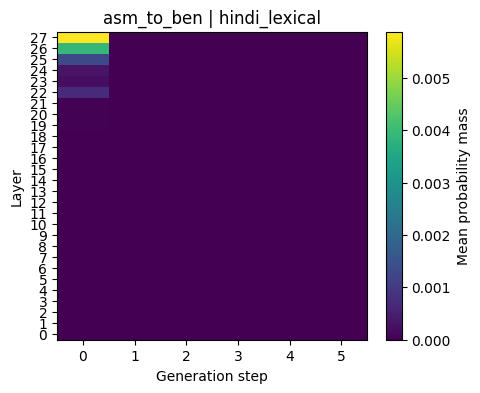

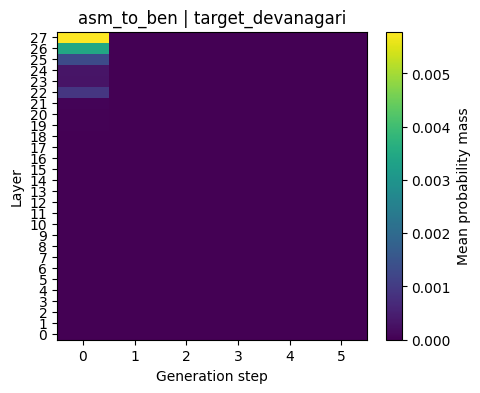

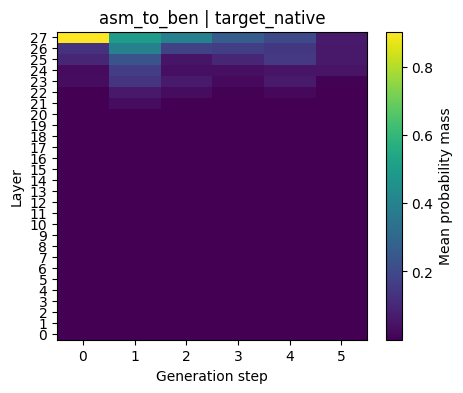

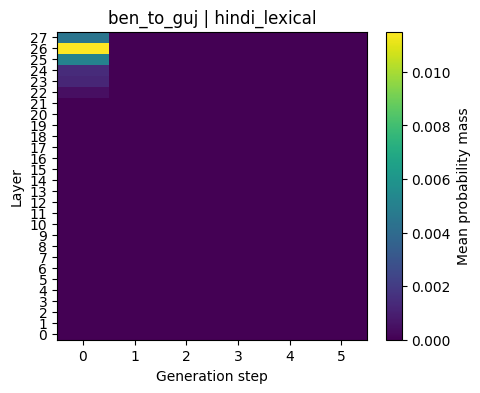

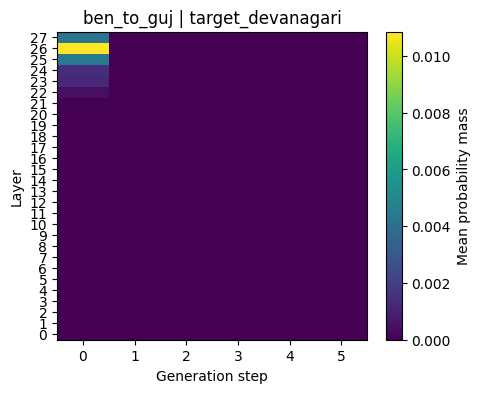

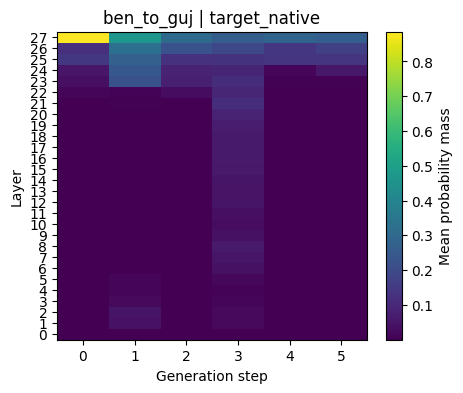

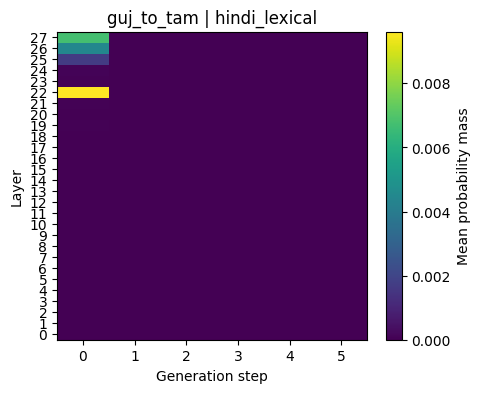

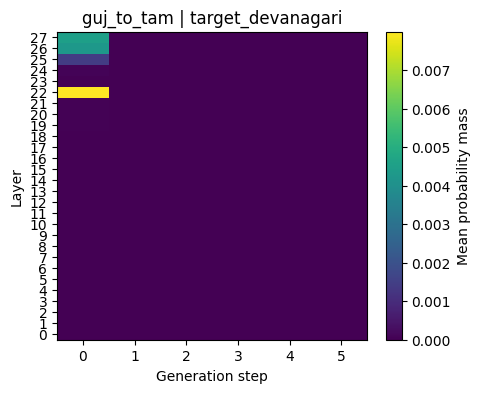

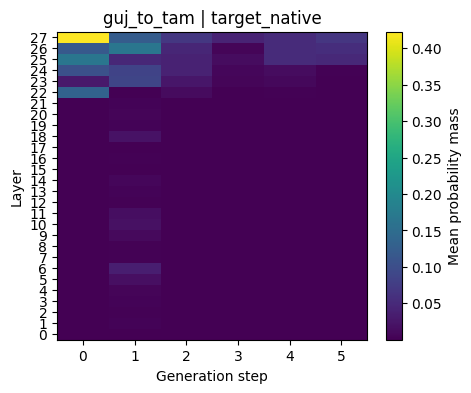

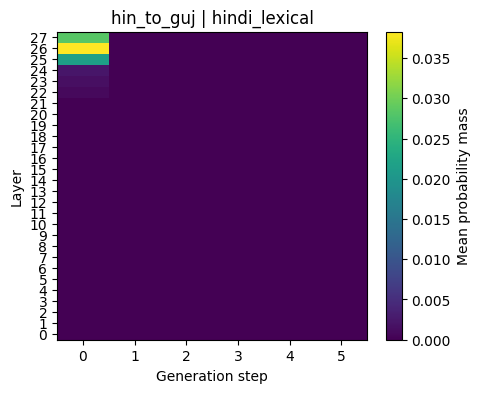

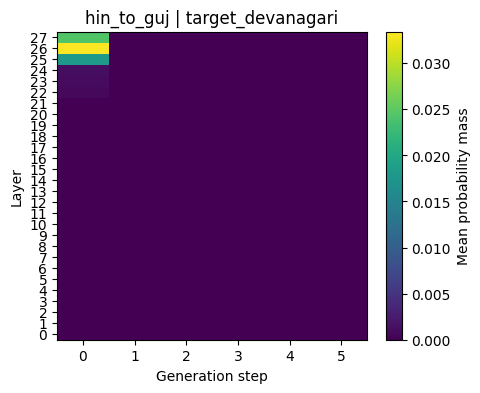

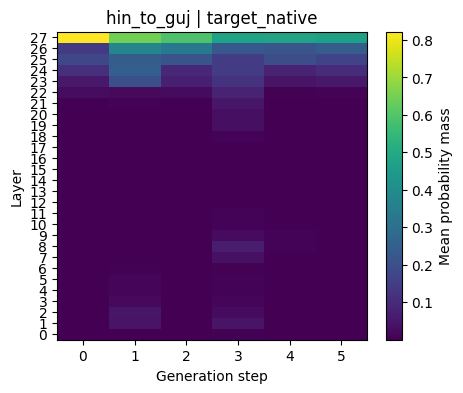

Auto-selected patch layers: [25, 26, 27]
Saved patch layer config to: /content/latent_bridge_outputs/patch_layers__Qwen__Qwen2.5-1.5B-Instruct.json


In [ ]:
WORD_SUMMARY_PATH = OUTPUT_DIR / f"word_bridge_summary__{PRIMARY_MODEL_ID.replace('/', '__')}.csv"
PATCH_LAYER_PATH = OUTPUT_DIR / f"patch_layers__{PRIMARY_MODEL_ID.replace('/', '__')}.json"

def summarize_trace_views(trace_df: pd.DataFrame, threshold: float = 0.10) -> pd.DataFrame:
    summary_rows: List[Dict[str, Any]] = []

    meta_cols = ["concept_en", "pair_name", "pair_class", "src_lang", "tgt_lang", "group"]

    for keys, sub in trace_df.groupby(meta_cols):
        concept_en, pair_name, pair_class, src_lang, tgt_lang, group = keys

        first_view = sub[sub["step"] == 0].groupby("layer", as_index=False)["mass"].mean()
        last_step = int(sub["step"].max())
        last_view = sub[sub["step"] == last_step].groupby("layer", as_index=False)["mass"].mean()
        all_view = sub.groupby("layer", as_index=False)["mass"].mean()

        for view_name, view_df in [("first", first_view), ("last", last_view), ("all", all_view)]:
            if view_df.empty:
                continue
            peak_idx = int(view_df["mass"].idxmax())
            peak_layer = int(view_df.loc[peak_idx, "layer"])
            peak_mass = float(view_df.loc[peak_idx, "mass"])
            above = view_df[view_df["mass"] >= threshold]
            onset_layer = int(above["layer"].min()) if len(above) else -1
            auc = float(view_df["mass"].sum())
            summary_rows.append(
                {
                    "concept_en": concept_en,
                    "pair_name": pair_name,
                    "pair_class": pair_class,
                    "src_lang": src_lang,
                    "tgt_lang": tgt_lang,
                    "group": group,
                    "view": view_name,
                    "peak_layer": peak_layer,
                    "peak_mass": peak_mass,
                    "onset_layer": onset_layer,
                    "auc": auc,
                }
            )

    return pd.DataFrame(summary_rows)

word_summary_df = summarize_trace_views(word_trace_df, threshold=LATENT_THRESHOLD)
word_summary_df.to_csv(WORD_SUMMARY_PATH, index=False)

aggregate_curve_df = (
    word_trace_df.groupby(["pair_name", "pair_class", "group", "layer", "step"], as_index=False)["mass"].mean()
)

display(word_summary_df.head(10))
display(
    aggregate_curve_df[
        aggregate_curve_df["group"].isin(["target_devanagari", "hindi_lexical", "target_native"])
    ].head(20)
)

# Quick heatmaps: one pair at a time, focusing on the most important groups.
for pair_name in aggregate_curve_df["pair_name"].drop_duplicates().tolist():
    pair_sub = aggregate_curve_df[
        (aggregate_curve_df["pair_name"] == pair_name)
        & (aggregate_curve_df["group"].isin(["target_devanagari", "hindi_lexical", "target_native"]))
    ]
    groups = pair_sub["group"].drop_duplicates().tolist()
    for group_name in groups:
        cur = pair_sub[pair_sub["group"] == group_name]
        pivot = cur.pivot_table(index="layer", columns="step", values="mass", aggfunc="mean").sort_index()
        plt.figure(figsize=(5, 4))
        plt.imshow(pivot.values, aspect="auto", origin="lower")
        plt.xticks(range(len(pivot.columns)), pivot.columns.tolist())
        plt.yticks(range(len(pivot.index)), pivot.index.tolist())
        plt.xlabel("Generation step")
        plt.ylabel("Layer")
        plt.title(f"{pair_name} | {group_name}")
        plt.colorbar(label="Mean probability mass")
        plt.show()

n_layers = len(get_transformer_layers(model))

dev_curve = (
    aggregate_curve_df[aggregate_curve_df["group"] == "target_devanagari"]
    .groupby("layer")["mass"]
    .mean()
    .sort_values(ascending=False)
)
if len(dev_curve) >= 3 and float(dev_curve.max()) > 0.0:
    patch_layers = sorted([int(x) for x in dev_curve.head(3).index.tolist()])
else:
    patch_layers = sorted(list({max(1, n_layers // 2), max(1, int(0.75 * n_layers)), max(1, n_layers - 2)}))

with open(PATCH_LAYER_PATH, "w", encoding="utf-8") as f:
    json.dump({"patch_layers": patch_layers}, f, indent=2)

print("Auto-selected patch layers:", patch_layers)
print(f"Saved patch layer config to: {PATCH_LAYER_PATH}")

## Cell 13 — activation patching helpers

**Why we are doing this:**  
This is the RQ2 cell. To avoid token-length mismatch errors across native, Romanized, Devanagari, and Hindi forms, the patching code injects a **single anchor vector** at the receiver span’s final token position. The donor vector is the mean hidden state over the donor source span.

**What you should expect as output:**  
Function definitions and a short note confirming that the hook-based patching path is ready.

In [ ]:
def kl_divergence(p: torch.Tensor, q: torch.Tensor) -> float:
    eps = 1e-12
    p = torch.clamp(p, eps, 1.0).double()
    q = torch.clamp(q, eps, 1.0).double()
    return float(torch.sum(p * (torch.log(p) - torch.log(q))).item())

def first_step_mass_from_probs(
    probs: torch.Tensor,
    tokenizer,
    candidate_texts: Iterable[str],
) -> float:
    seqs = build_candidate_sequences(tokenizer, candidate_texts)
    first_ids = sorted({seq[0] for seq in seqs if len(seq) > 0})
    return float(probs[first_ids].sum().item()) if first_ids else 0.0

def get_source_prompt_parts_for_variant(lang_code: str, source_text: str) -> Tuple[str, str, str]:
    prefix = f"Translate the following {LANG_INFO[lang_code]['name']} word into English.\nWord: "
    suffix = "\nAnswer:"
    return prefix, source_text, suffix

def extract_donor_vector(
    model,
    inputs: Dict[str, torch.Tensor],
    span_positions: Sequence[int],
    layer_idx: int,
) -> torch.Tensor:
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )
    # hidden_states[0] is the embedding output; hidden_states[layer_idx + 1] is after layer_idx
    donor_h = outputs.hidden_states[layer_idx + 1][0, list(span_positions), :].mean(dim=0)
    return donor_h.detach()

def run_patched_receiver_probs(
    model,
    receiver_inputs: Dict[str, torch.Tensor],
    receiver_anchor_pos: int,
    donor_vec: torch.Tensor,
    layer_idx: int,
) -> torch.Tensor:
    layers = get_transformer_layers(model)
    donor_vec = donor_vec.to(DEVICE)

    def patch_hook(module, module_inputs, module_output):
        if isinstance(module_output, tuple):
            hidden = module_output[0]
            patched = hidden.clone()
            patched[:, receiver_anchor_pos, :] = donor_vec.to(hidden.device, hidden.dtype)
            return (patched,) + module_output[1:]
        else:
            patched = module_output.clone()
            patched[:, receiver_anchor_pos, :] = donor_vec.to(module_output.device, module_output.dtype)
            return patched

    handle = layers[layer_idx].register_forward_hook(patch_hook)
    try:
        with torch.no_grad():
            outputs = model(
                **receiver_inputs,
                use_cache=False,
                return_dict=True,
            )
        probs = torch.softmax(outputs.logits[0, -1, :].float(), dim=-1).cpu()
    finally:
        handle.remove()
    return probs

print("Activation patching helpers are ready.")

Activation patching helpers are ready.


## Cell 14 — run activation patching on the selected subset

**Why we are doing this:**  
This compares four donor conditions for the same concept: native, Romanized, Devanagari-transliterated, and Hindi lexical. The receiver prompt stays fixed as the native source-to-English prompt. We then compare each patched next-token distribution to the native-patched reference.

**What you should expect as output:**  
A CSV of patching results and a compact table with mean KL divergence by donor type and layer.

In [ ]:
PATCH_RESULTS_PATH = OUTPUT_DIR / f"patching_results__{PRIMARY_MODEL_ID.replace('/', '__')}.csv"

def select_patch_probe_subset(df: pd.DataFrame, per_pair_limit: int) -> pd.DataFrame:
    chunks = []
    for spec in PAIR_SPECS:
        sub = df[df["pair_name"] == spec["name"]].head(per_pair_limit)
        chunks.append(sub)
    return pd.concat(chunks, ignore_index=True)

if PATCH_RESULTS_PATH.exists():
    patch_results_df = pd.read_csv(PATCH_RESULTS_PATH)
else:
    selected_patch_probes = select_patch_probe_subset(word_probe_df, PATCH_PROBE_LIMIT_PER_PAIR)
    patch_rows: List[Dict[str, Any]] = []

    for probe_row in tqdm(selected_patch_probes.to_dict(orient="records"), total=len(selected_patch_probes)):
        receiver_prefix, receiver_word, receiver_suffix = get_source_prompt_parts_for_variant(
            probe_row["src_lang"], probe_row["src_native"]
        )
        _, receiver_inputs, receiver_span_positions = encode_prompt_with_marked_span(
            tokenizer=tokenizer,
            prefix=receiver_prefix,
            span_text=receiver_word,
            suffix=receiver_suffix,
            device=DEVICE,
        )
        receiver_anchor_pos = int(receiver_span_positions[-1])

        donor_variants = {
            "native": (probe_row["src_lang"], probe_row["src_native"]),
            "roman": (probe_row["src_lang"], probe_row["src_roman"]),
            "devanagari": (probe_row["src_lang"], probe_row["src_devanagari"]),
            "hindi": ("hin_Deva", probe_row["hindi_native"]),
        }

        for layer_idx in patch_layers:
            donor_probs: Dict[str, torch.Tensor] = {}
            english_first_step_mass: Dict[str, float] = {}

            for donor_name, (donor_lang, donor_text) in donor_variants.items():
                donor_prefix, donor_word, donor_suffix = get_source_prompt_parts_for_variant(donor_lang, donor_text)
                _, donor_inputs, donor_span_positions = encode_prompt_with_marked_span(
                    tokenizer=tokenizer,
                    prefix=donor_prefix,
                    span_text=donor_word,
                    suffix=donor_suffix,
                    device=DEVICE,
                )
                donor_vec = extract_donor_vector(
                    model=model,
                    inputs=donor_inputs,
                    span_positions=donor_span_positions,
                    layer_idx=layer_idx,
                )
                probs = run_patched_receiver_probs(
                    model=model,
                    receiver_inputs=receiver_inputs,
                    receiver_anchor_pos=receiver_anchor_pos,
                    donor_vec=donor_vec,
                    layer_idx=layer_idx,
                )
                donor_probs[donor_name] = probs
                english_first_step_mass[donor_name] = first_step_mass_from_probs(
                    probs=probs,
                    tokenizer=tokenizer,
                    candidate_texts=[probe_row["concept_en"], probe_row["concept_en"].lower()],
                )

            native_probs = donor_probs["native"]
            for donor_name in ["native", "roman", "devanagari", "hindi"]:
                patch_rows.append(
                    {
                        "concept_en": probe_row["concept_en"],
                        "pair_name": probe_row["pair_name"],
                        "pair_class": probe_row["pair_class"],
                        "src_lang": probe_row["src_lang"],
                        "layer": layer_idx,
                        "donor_type": donor_name,
                        "kl_to_native": kl_divergence(donor_probs[donor_name], native_probs),
                        "english_first_step_mass": english_first_step_mass[donor_name],
                    }
                )

    patch_results_df = pd.DataFrame(patch_rows)
    patch_results_df.to_csv(PATCH_RESULTS_PATH, index=False)

print(f"Saved patching results to: {PATCH_RESULTS_PATH}")
display(patch_results_df.head(12))
display(
    patch_results_df.groupby(["donor_type", "layer"], as_index=False)
    .agg(
        mean_kl_to_native=("kl_to_native", "mean"),
        mean_english_first_step_mass=("english_first_step_mass", "mean"),
    )
    .sort_values(["layer", "mean_kl_to_native"], ascending=[True, True])
)

  0%|          | 0/40 [00:00<?, ?it/s]

Saved patching results to: /content/latent_bridge_outputs/patching_results__Qwen__Qwen2.5-1.5B-Instruct.csv


,concept_en,pair_name,pair_class,src_lang,layer,donor_type,kl_to_native,english_first_step_mass
0,water,ben_to_guj,test_cross_script_same_family,ben_Beng,25,native,0.000000,0.350179
1,water,ben_to_guj,test_cross_script_same_family,ben_Beng,25,roman,0.049606,0.356512
2,water,ben_to_guj,test_cross_script_same_family,ben_Beng,25,devanagari,0.000607,0.344897
3,water,ben_to_guj,test_cross_script_same_family,ben_Beng,25,hindi,0.000445,0.347252
4,water,ben_to_guj,test_cross_script_same_family,ben_Beng,26,native,0.000000,0.342703
5,water,ben_to_guj,test_cross_script_same_family,ben_Beng,26,roman,0.021849,0.354708
6,water,ben_to_guj,test_cross_script_same_family,ben_Beng,26,devanagari,0.001006,0.335198
7,water,ben_to_guj,test_cross_script_same_family,ben_Beng,26,hindi,0.000704,0.334417
8,water,ben_to_guj,test_cross_script_same_family,ben_Beng,27,native,0.000000,0.322848
9,water,ben_to_guj,test_cross_script_same_family,ben_Beng,27,roman,0.000000,0.322848


,donor_type,layer,mean_kl_to_native,mean_english_first_step_mass
6,native,25,0.000000,0.374107
0,devanagari,25,0.000286,0.374939
3,hindi,25,0.000393,0.373955
9,roman,25,0.004616,0.379657
7,native,26,0.000000,0.371937
1,devanagari,26,0.000250,0.372581
4,hindi,26,0.000395,0.371241
10,roman,26,0.002129,0.377474
2,devanagari,27,0.000000,0.372075
5,hindi,27,0.000000,0.372075


In [ ]:
SENTENCE_EVAL_PATH = OUTPUT_DIR / f"sentence_eval__{PRIMARY_MODEL_ID.replace('/', '__')}.csv"
chrf_metric = CHRF(word_order=2)

def generate_text(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 64,
) -> str:
    enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
    enc = {k: v.to(DEVICE) for k, v in enc.items() if k != "token_type_ids"}
    if "attention_mask" not in enc:
        enc["attention_mask"] = torch.ones_like(enc["input_ids"], device=DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **enc,
            do_sample=False,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_ids = output_ids[0, enc["input_ids"].shape[1] :]
    text = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return text.splitlines()[0].strip() if text else ""

def script_fraction(text: str, expected_script: str) -> float:
    labels = [
        script_of_char(ch)
        for ch in safe_text(text)
        if script_of_char(ch) not in {"Space", "Punct", "Number", "Other"}
    ]
    if not labels:
        return 0.0
    return float(sum(lbl == expected_script for lbl in labels) / len(labels))

def build_condition_source(row: Dict[str, Any], condition: str) -> Tuple[str, str]:
    if condition == "direct_native":
        return row["src_lang_name"], row["src_text"]
    if condition == "english_source":
        return "English", row["english_text"]
    if condition == "roman_source":
        return f"Romanized {row['src_lang_name']}", row["src_roman"]
    if condition == "devanagari_source":
        return f"Devanagari-transliterated {row['src_lang_name']}", row["src_devanagari"]
    if condition == "hindi_source":
        return "Hindi", row["hindi_text"]
    raise ValueError(f"Unknown condition: {condition}")

CONDITIONS = [
    "direct_native",
    "english_source",
    "roman_source",
    "devanagari_source",
    "hindi_source",
]

if SENTENCE_EVAL_PATH.exists():
    sentence_eval_df = pd.read_csv(SENTENCE_EVAL_PATH)
else:
    eval_rows: List[Dict[str, Any]] = []
    selected_sentence_df = sentence_probe_df.copy()

    for row in tqdm(selected_sentence_df.to_dict(orient="records"), total=len(selected_sentence_df)):
        expected_script = LANG_INFO[row["tgt_lang"]]["script_label"]

        for condition in CONDITIONS:
            src_label, source_text = build_condition_source(row, condition)
            prompt = make_sentence_translation_prompt(
                src_label=src_label,
                tgt_lang=row["tgt_lang"],
                source_text=source_text,
            )
            generated_text = generate_text(
                model=model,
                tokenizer=tokenizer,
                prompt=prompt,
                max_new_tokens=SENTENCE_MAX_NEW_TOKENS,
            )
            eval_rows.append(
                {
                    "id": int(row["id"]),
                    "pair_name": row["pair_name"],
                    "pair_class": row["pair_class"],
                    "src_lang": row["src_lang"],
                    "tgt_lang": row["tgt_lang"],
                    "condition": condition,
                    "generated_text": generated_text,
                    "reference_text": row["tgt_text"],
                    "chrf": chrf_metric.sentence_score(generated_text, [row["tgt_text"]]).score,
                    "script_fraction": script_fraction(generated_text, expected_script),
                }
            )

    sentence_eval_df = pd.DataFrame(eval_rows)
    sentence_eval_df.to_csv(SENTENCE_EVAL_PATH, index=False)

print(f"Saved sentence evaluation to: {SENTENCE_EVAL_PATH}")
display(sentence_eval_df.head(12))
display(
    sentence_eval_df.groupby(["pair_name", "condition"], as_index=False)
    .agg(
        mean_chrf=("chrf", "mean"),
        mean_script_fraction=("script_fraction", "mean"),
    )
    .sort_values(["pair_name", "mean_chrf"], ascending=[True, False])
)

  0%|          | 0/40 [00:00<?, ?it/s]

Saved sentence evaluation to: /content/latent_bridge_outputs/sentence_eval__Qwen__Qwen2.5-1.5B-Instruct.csv


,id,pair_name,pair_class,src_lang,tgt_lang,condition,generated_text,reference_text,chrf,script_fraction
0,4,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,direct_native,પાઇલ્ટનું સ્કોયાડર અથવા લિડાબોટ માટે વધુ,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,9.573157,1.000000
1,4,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,english_source,પ્રધાનમંત્રી દિલોકૃત પત્વે સુગણ કરે છે. Transl...,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,9.473306,0.750000
2,4,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,roman_source,પાઇલાત્તિસ્કોઅડ્રનને લિડારા દિલોકીય પટઠ�,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,13.079892,1.000000
3,4,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,devanagari_source,પાઇલ્ટિટી સ્કોયાડરન લિડાર દિલોકૃત પાત્તાભ,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,12.792917,1.000000
4,4,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,hindi_source,પાઇલ્ડ માટે સ્કવાર્ન લીડર દિલોકૃત પટાવી છે. Tr...,પાઇલટની ઓળખ સ્ક્વૉડ્રન લીડર ડિલોક્રિટ પૅટ્ટાવી...,18.699551,0.765957
5,6,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,direct_native,"એક્ટેમાં વર્ષોનું પ્રતિશાળી ભિડાળ જેવી છે,",28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,8.435733,1.000000
6,6,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,english_source,વિડીલો એક ત્રણામાં છે જે પહેલું સૌથી આગળ બાર,28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,11.756104,1.000000
7,6,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,roman_source,બાયટીલે ભિડાળનું સમાવેશ છે જ્યારે તે મધ્�,28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,7.606598,1.000000
8,6,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,devanagari_source,એક્ટરાંગેશન પર વિચારવામાં આવી હતી. Translation:,28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,7.430935,0.725000
9,6,ben_to_guj,test_cross_script_same_family,ben_Beng,guj_Gujr,hindi_source,એક્સપોરેટ કરતી છે જે પ્રમાણને આપવામાં આવ્યુ�,28 વર્ષના વિદાલ ત્રણ સિઝન પહેલા બારકા સાથે જોડ...,6.607498,1.000000


,pair_name,condition,mean_chrf,mean_script_fraction
0,asm_to_ben,devanagari_source,13.745977,0.984106
2,asm_to_ben,english_source,11.935160,0.979724
4,asm_to_ben,roman_source,10.957328,0.989577
1,asm_to_ben,direct_native,10.040629,0.796667
3,asm_to_ben,hindi_source,9.198081,0.515959
5,ben_to_guj,devanagari_source,11.485411,0.872500
8,ben_to_guj,hindi_source,9.214025,0.851014
6,ben_to_guj,direct_native,9.136122,0.962963
9,ben_to_guj,roman_source,8.917634,0.975556
7,ben_to_guj,english_source,8.631911,0.952083


## Cell 15 — sentence-level explicit-pivot evaluation

**Why we are doing this:**  
This is the utility follow-up. It compares five source conditions for sentence translation: native source, English source, Romanized source, Devanagari-transliterated source, and Hindi source. It measures chrF against the FLORES reference and a simple script-correctness score.

**What you should expect as output:**  
A CSV of generated sentence outputs and a summary table by pair and condition.

## Cell 16 — verify the checklist and the key output files

**Why we are doing this:**  
This last cell checks that every planned artifact exists and that each one is non-empty. It also prints the automatically selected patch layers and the sizes of the key dataframes.

**What you should expect as output:**  
A checklist table with PASS / FAIL status. If anything failed, rerun the missing cell before scaling the experiment up.

In [ ]:
def file_status(path: pathlib.Path) -> str:
    return "PASS" if path.exists() and path.stat().st_size > 0 else "FAIL"

checklist_rows = [
    {"item": "bootstrap lexicon created", "status": file_status(BOOTSTRAP_PATH), "path": str(BOOTSTRAP_PATH)},
    {"item": "derived lexicon created", "status": file_status(LEXICON_DERIVED_PATH), "path": str(LEXICON_DERIVED_PATH)},
    {"item": "tokenizer audit created", "status": file_status(TOKEN_AUDIT_PATH), "path": str(TOKEN_AUDIT_PATH)},
    {"item": "word probe table created", "status": file_status(WORD_PROBE_PATH), "path": str(WORD_PROBE_PATH)},
    {"item": "sentence probe subset created", "status": file_status(SENTENCE_PROBE_PATH), "path": str(SENTENCE_PROBE_PATH)},
    {"item": "word bridge traces created", "status": file_status(WORD_TRACE_PATH), "path": str(WORD_TRACE_PATH)},
    {"item": "word bridge summary created", "status": file_status(WORD_SUMMARY_PATH), "path": str(WORD_SUMMARY_PATH)},
    {"item": "patch layer config created", "status": file_status(PATCH_LAYER_PATH), "path": str(PATCH_LAYER_PATH)},
    {"item": "patching results created", "status": file_status(PATCH_RESULTS_PATH), "path": str(PATCH_RESULTS_PATH)},
    {"item": "sentence evaluation created", "status": file_status(SENTENCE_EVAL_PATH), "path": str(SENTENCE_EVAL_PATH)},
]

checklist_df = pd.DataFrame(checklist_rows)
display(checklist_df)

print("Dataframe sizes:")
print("  lexicon_bootstrap:", len(lexicon_bootstrap))
print("  lexicon_df:", len(lexicon_df))
print("  word_probe_df:", len(word_probe_df))
print("  sentence_probe_df:", len(sentence_probe_df))
print("  word_trace_df:", len(word_trace_df))
print("  patch_results_df:", len(patch_results_df))
print("  sentence_eval_df:", len(sentence_eval_df))

with open(PATCH_LAYER_PATH, "r", encoding="utf-8") as f:
    patch_meta = json.load(f)
print("Patch layers:", patch_meta["patch_layers"])

if (checklist_df["status"] == "PASS").all():
    print("All checklist items passed.")
else:
    print("At least one checklist item failed. Rerun the corresponding cell before moving on.")

,item,status,path
0,bootstrap lexicon created,PASS,/content/latent_bridge_outputs/concept_lexicon...
1,derived lexicon created,PASS,/content/latent_bridge_outputs/concept_lexicon...
2,tokenizer audit created,PASS,/content/latent_bridge_outputs/token_audit__Qw...
3,word probe table created,PASS,/content/latent_bridge_outputs/word_probe_pair...
4,sentence probe subset created,PASS,/content/latent_bridge_outputs/sentence_probe_...
5,word bridge traces created,PASS,/content/latent_bridge_outputs/word_bridge_tra...
6,word bridge summary created,PASS,/content/latent_bridge_outputs/word_bridge_sum...
7,patch layer config created,PASS,/content/latent_bridge_outputs/patch_layers__Q...
8,patching results created,PASS,/content/latent_bridge_outputs/patching_result...
9,sentence evaluation created,PASS,/content/latent_bridge_outputs/sentence_eval__...


Dataframe sizes:
  lexicon_bootstrap: 40
  lexicon_df: 360
  word_probe_df: 160
  sentence_probe_df: 40
  word_trace_df: 50400
  patch_results_df: 480
  sentence_eval_df: 200
Patch layers: [25, 26, 27]
All checklist items passed.
